# Decoding Customer Value: A SQL-Driven Retention Strategy
### IIT Guwahati Summer Projects '26

**Objective:** Analyze customer transactional and behavioral data to identify high-value customers, quantify promotional dependency, and design a data-backed retention strategy for a D2C fashion brand.

In [1]:
import pandas as pd
import numpy as np

## 1. Data Loading

The raw customer dataset is loaded into a Pandas DataFrame for preprocessing and exploratory analysis.

In [2]:
df = pd.read_csv("raw_customer_dataset.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. Exploratory Data Analysis (EDA)

This section explores the dataset structure, data types, missing values, and overall characteristics before any preprocessing is performed.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## 3. Data Cleaning

The dataset is cleaned by removing duplicate records, checking for missing values, and validating data quality to ensure reliable downstream analysis.

In [8]:
df = df.drop_duplicates()

In [9]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [10]:
df['Gender'] = df['Gender'].str.strip().str.title()

In [11]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [12]:
df['Frequency of Purchases'].unique()

<StringArray>
[   'Fortnightly',         'Weekly',       'Annually',      'Quarterly',
      'Bi-Weekly',        'Monthly', 'Every 3 Months']
Length: 7, dtype: str

In [13]:
df['Payment Method'].unique()

<StringArray>
['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer', 'Debit Card']
Length: 6, dtype: str

In [14]:
df['Shipping Type'].unique()

<StringArray>
[       'Express',  'Free Shipping',   'Next Day Air',       'Standard',
 '2-Day Shipping',   'Store Pickup']
Length: 6, dtype: str

In [15]:
df['Category'].unique()

<StringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str

In [16]:
df.to_csv("cleaned_customer_data.csv", index=False)

In [17]:
def value_tier(x):
    if x > 80:
        return 'High Value'
    elif x >= 40:
        return 'Medium Value'
    else:
        return 'Low Value'

df['Value Tier'] = df['Purchase Amount (USD)'].apply(value_tier)

In [18]:
df['Purchase Amount (USD)'].describe()

count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64

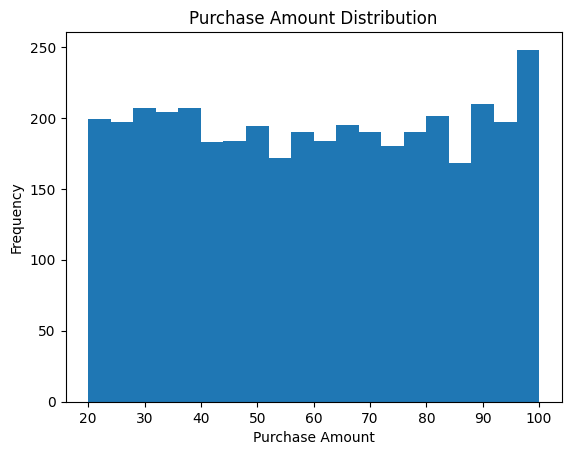

In [19]:
import matplotlib.pyplot as plt

plt.hist(df['Purchase Amount (USD)'], bins=20)
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.title('Purchase Amount Distribution')
plt.show()

In [20]:
df['Purchase Amount (USD)'].quantile([0.25, 0.50, 0.75, 0.90])

0.25    39.0
0.50    60.0
0.75    81.0
0.90    93.0
Name: Purchase Amount (USD), dtype: float64

In [21]:
def value_tier(x):
    if x < 39:
        return 'Low Value'
    elif x <= 81:
        return 'Medium Value'
    elif x <= 93:
        return 'High Value'
    else :
        return 'elite'

df['Value Tier'] = df['Purchase Amount (USD)'].apply(value_tier)

In [22]:
df[['Purchase Amount (USD)', 'Value Tier']].head()

,Purchase Amount (USD),Value Tier
0,53,Medium Value
1,64,Medium Value
2,73,Medium Value
3,90,High Value
4,49,Medium Value


In [23]:
df.groupby('Value Tier')['Purchase Amount (USD)'].agg(['min','max','mean','count'])

,min,max,mean,count
Value Tier,,,,
High Value,82,93,87.451327,565
Low Value,20,38,29.098867,971
Medium Value,39,81,60.147778,2003
elite,94,100,96.786704,361


In [24]:
df.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases',
 'Value Tier']

## 4. Feature Engineering

Business-oriented features are engineered to better capture customer value, promotional reliance, and long-term retention behavior. These features form the foundation for subsequent SQL analysis.

In [25]:
import pandas as pd
import numpy as np

# ── 1. PROMO DEPENDENCY SCORE ──────────────────────────────────────────────
# How reliant is a customer on discounts/promos to make a purchase
df['Discount Applied'] = df['Discount Applied'].map({'Yes': 1, 'No': 0})
df['Promo Code Used']  = df['Promo Code Used'].map({'Yes': 1, 'No': 0})

df['Promo_Dependency_Score'] = (df['Discount Applied'] + df['Promo Code Used']) / 2
# 0 = never uses promos | 0.5 = uses one | 1.0 = always uses both

# ── 2. VALUE TIER ──────────────────────────────────────────────────────────
# Based on Purchase Amount + Previous Purchases combined score
df['Spend_Score']     = pd.qcut(df['Purchase Amount (USD)'], q=3, labels=[1,2,3]).astype(int)
df['Frequency_Score'] = pd.qcut(df['Previous Purchases'],   q=3, labels=[1,2,3]).astype(int)
df['Value_Score']     = df['Spend_Score'] + df['Frequency_Score']

df['Value_Tier'] = pd.cut(df['Value_Score'],
                           bins=[1, 3, 4, 6],
                           labels=['Low', 'Mid', 'High'],
                           include_lowest=True)

# ── 3. SATISFACTION FLAG ──────────────────────────────────────────────────
# Review Rating >= 4.0 → Satisfied | < 3.0 → At Risk | else → Neutral
df['Satisfaction_Flag'] = np.where(df['Review Rating'] >= 4.0, 'Satisfied',
                          np.where(df['Review Rating'] <  3.0, 'At_Risk', 'Neutral'))

# ── 4. CUSTOMER TENURE BUCKET ─────────────────────────────────────────────
df['Tenure_Bucket'] = pd.cut(df['Previous Purchases'],
                              bins=[0, 10, 25, 40, 50],
                              labels=['New', 'Growing', 'Established', 'Loyal'])

# ── 5. AGE GROUP ──────────────────────────────────────────────────────────
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[17, 25, 35, 45, 55, 70],
                          labels=['18-25','26-35','36-45','46-55','56+'])

# ── VERIFY ────────────────────────────────────────────────────────────────
print(df[['Promo_Dependency_Score','Value_Tier','Satisfaction_Flag',
          'Tenure_Bucket','Age_Group']].head(10))
print("\nValue Tier Distribution:\n",  df['Value_Tier'].value_counts())
print("\nSatisfaction Distribution:\n", df['Satisfaction_Flag'].value_counts())
print("\nPromo Dependency Stats:\n",    df['Promo_Dependency_Score'].value_counts())

   Promo_Dependency_Score Value_Tier Satisfaction_Flag Tenure_Bucket Age_Group
0                     1.0        Low           Neutral       Growing     46-55
1                     1.0        Low           Neutral           New     18-25
2                     1.0        Mid           Neutral       Growing     46-55
3                     1.0       High           Neutral         Loyal     18-25
4                     1.0        Mid           At_Risk   Established     36-45
5                     1.0        Low           At_Risk       Growing     46-55
6                     1.0       High           Neutral         Loyal       56+
7                     1.0        Low           Neutral       Growing     26-35
8                     1.0        Mid           At_Risk           New     26-35
9                     1.0        Low         Satisfied           New       56+

Value Tier Distribution:
 Value_Tier
Mid     1369
Low     1272
High    1259
Name: count, dtype: int64

Satisfaction Distribution:


In [26]:
df.to_csv('customers_engineered.csv', index=False)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (3900, 27)
Columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'Value Tier', 'Promo_Dependency_Score', 'Spend_Score', 'Frequency_Score', 'Value_Score', 'Value_Tier', 'Satisfaction_Flag', 'Tenure_Bucket', 'Age_Group']


In [27]:
df.drop(columns=['Value Tier', 'Spend_Score', 'Frequency_Score', 'Value_Score'], inplace=True)
df.to_csv('customers_engineered.csv', index=False)
print(df.shape)
print(df.columns.tolist())

(3900, 23)
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'Promo_Dependency_Score', 'Value_Tier', 'Satisfaction_Flag', 'Tenure_Bucket', 'Age_Group']


## 5. SQL Database Construction

The engineered dataset is exported into an SQLite database, enabling SQL-based segmentation and business intelligence analysis.

In [28]:

import sqlite3
import pandas as pd

# Load engineered dataset
df = pd.read_csv("customers_engineered.csv")

# Create/connect to SQLite database
conn = sqlite3.connect("customers.db")

# Export dataframe to SQL table
df.to_sql(
    name="customers",
    con=conn,
    if_exists="replace",
    index=False
)

# Verify successful database creation
# Verify successful database creation
record_count = pd.read_sql_query(
    "SELECT COUNT(*) AS Total_Records FROM customers",
    conn
)

print(record_count)
print("✅ SQLite database 'customers.db' created successfully.")

   Total_Records
0           3900
✅ SQLite database 'customers.db' created successfully.


## 6. Customer Segmentation & SQL Analysis

SQL queries are used to answer the core business questions related to customer value, promotional dependency, geographic opportunities, and retention patterns.

In [29]:
# Verify available columns
print(pd.read_sql_query("SELECT * FROM customers LIMIT 1", conn).columns.tolist())

# -----------------------------
# Q1. Customer Value Tiers
# -----------------------------
q1 = pd.read_sql_query("""
SELECT
    Value_Tier,
    ROUND(AVG([Purchase Amount (USD)]), 2) AS Avg_Spend,
    ROUND(AVG([Previous Purchases]), 2) AS Avg_Purchases,
    ROUND(AVG([Review Rating]), 2) AS Avg_Rating,
    ROUND(AVG(Promo_Dependency_Score), 2) AS Avg_Promo_Dependency,
    COUNT(*) AS Total_Customers
FROM customers
GROUP BY Value_Tier
ORDER BY Avg_Spend DESC;
""", conn)

print("Q1:")
print(q1)

# -----------------------------
# Q2. Tenure & Category Analysis
# -----------------------------
q2 = pd.read_sql_query("""
SELECT
    Tenure_Bucket,
    Category,
    Season,
    COUNT(*) AS Purchase_Count,
    ROUND(AVG([Purchase Amount (USD)]), 2) AS Avg_Spend
FROM customers
GROUP BY Tenure_Bucket, Category, Season
ORDER BY Purchase_Count DESC;
""", conn)

print("Q2:")
print(q2)

# -----------------------------
# Q3. Geography Analysis
# -----------------------------
q3 = pd.read_sql_query("""
SELECT
    Location,
    COUNT(*) AS Total_Customers,
    ROUND(AVG([Purchase Amount (USD)]), 2) AS Avg_Spend,
    SUM([Promo Code Used]) AS Promo_Users,
    ROUND(SUM([Promo Code Used]) * 100.0 / COUNT(*), 2) AS Promo_Pct
FROM customers
GROUP BY Location
ORDER BY Promo_Pct ASC;
""", conn)

print("Q3:")
print(q3)

# -----------------------------
# Q4. Promo Dependency Analysis
# -----------------------------
q4 = pd.read_sql_query("""
SELECT
    Promo_Dependency_Score,
    Value_Tier,
    COUNT(*) AS Customers,
    ROUND(AVG([Previous Purchases]), 2) AS Avg_Purchases,
    ROUND(AVG([Purchase Amount (USD)]), 2) AS Avg_Spend
FROM customers
GROUP BY Promo_Dependency_Score, Value_Tier
ORDER BY Promo_Dependency_Score DESC;
""", conn)

print("Q4:")
print(q4)

# -----------------------------
# Q5. Purchase Frequency Analysis
# -----------------------------
q5 = pd.read_sql_query("""
SELECT
    [Frequency of Purchases],
    Value_Tier,
    Satisfaction_Flag,
    COUNT(*) AS Customers,
    ROUND(AVG([Purchase Amount (USD)]), 2) AS Avg_Spend,
    ROUND(AVG([Previous Purchases]), 2) AS Avg_History
FROM customers
GROUP BY
    [Frequency of Purchases],
    Value_Tier,
    Satisfaction_Flag
ORDER BY Avg_History DESC;
""", conn)

print("Q5:")
print(q5)

# -----------------------------
# Export Results
# -----------------------------
q1.to_csv("q1_value_tiers.csv", index=False)
q2.to_csv("q2_tenure_category.csv", index=False)
q3.to_csv("q3_geography.csv", index=False)
q4.to_csv("q4_promo_retention.csv", index=False)
q5.to_csv("q5_frequency.csv", index=False)

print("✅ SQL outputs exported successfully.")

# Close database connection AFTER all SQL work is complete
conn.close()
print("✅ Database connection closed.")

['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'Promo_Dependency_Score', 'Value_Tier', 'Satisfaction_Flag', 'Tenure_Bucket', 'Age_Group']
Q1:
  Value_Tier  Avg_Spend  Avg_Purchases  Avg_Rating  Avg_Promo_Dependency  \
0       High      78.15          36.94        3.79                  0.44   
1        Mid      60.38          24.96        3.72                  0.43   
2        Low      40.90          14.30        3.74                  0.42   

   Total_Customers  
0             1259  
1             1369  
2             1272  
Q2:
   Tenure_Bucket   Category  Season  Purchase_Count  Avg_Spend
0    Established   Clothing  Winter             142      62.79
1    Established   Clothing  Spring             141      59.94
2        Growing   Clothing  Sprin

## 7. Founder Dashboard

A visual dashboard is generated to help non-technical stakeholders understand customer value distribution, retention drivers, and promotional dependency.

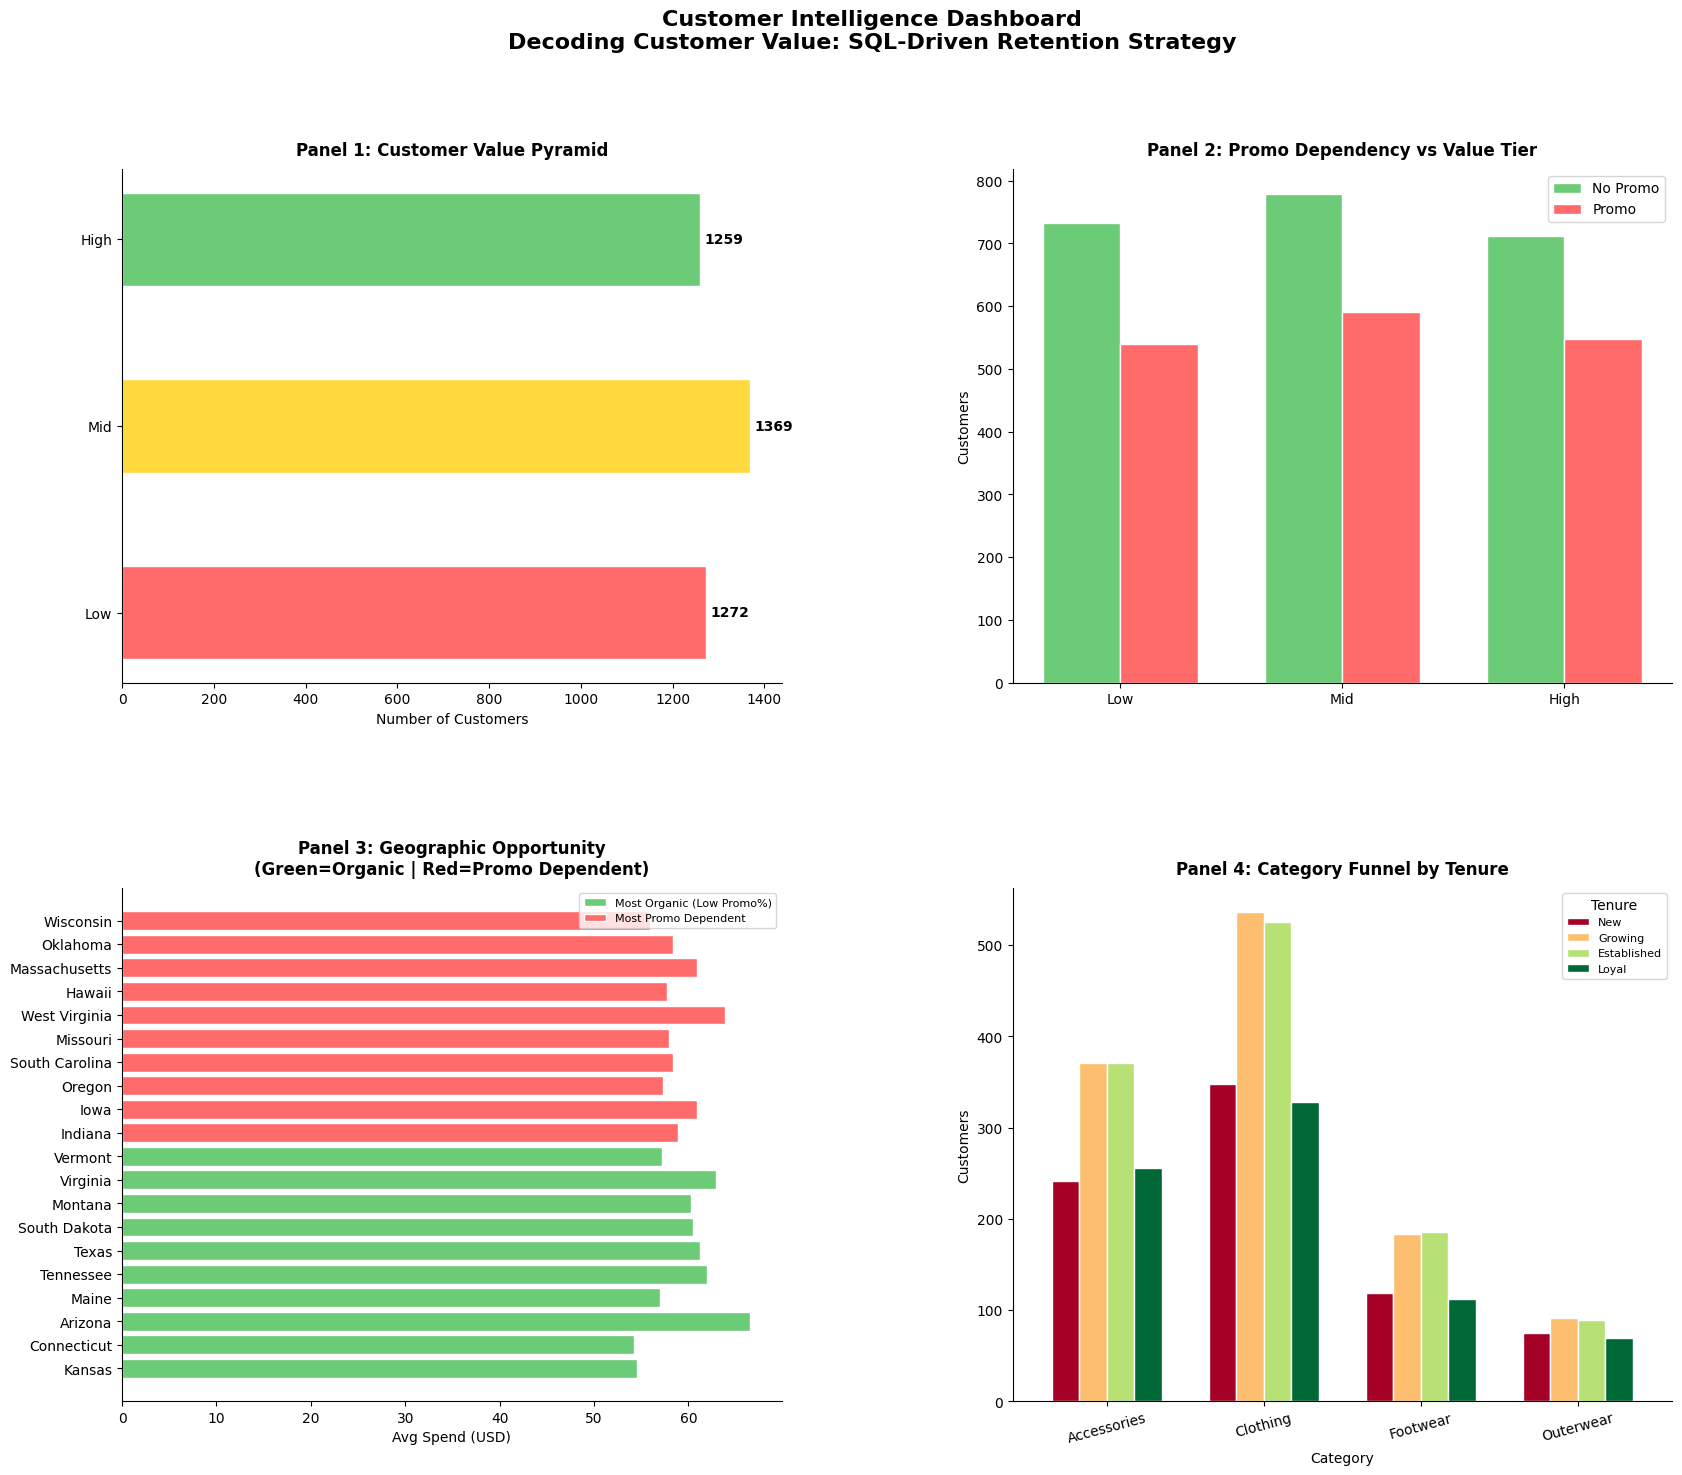

Dashboard saved


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Load data
# Load data
q1 = pd.read_csv("q1_value_tiers.csv")
q3 = pd.read_csv("q3_geography.csv")
q4 = pd.read_csv("q4_promo_retention.csv")
q5 = pd.read_csv("q5_frequency.csv")
df = pd.read_csv("customers_engineered.csv")

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Customer Intelligence Dashboard\nDecoding Customer Value: SQL-Driven Retention Strategy',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── PANEL 1: Customer Pyramid ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
tiers = ['Low', 'Mid', 'High']
counts = [q1.loc[q1['Value_Tier']==t, 'Total_Customers'].values[0] for t in tiers]
colors = ['#ff6b6b','#ffd93d','#6bcb77']
bars = ax1.barh(tiers, counts, color=colors, edgecolor='white', height=0.5)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
             f'{count}', va='center', fontweight='bold')
ax1.set_title('Panel 1: Customer Value Pyramid', fontweight='bold', pad=10)
ax1.set_xlabel('Number of Customers')
ax1.spines[['top','right']].set_visible(False)

# ── PANEL 2: Promo Dependency vs Retention ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
promo = q4[q4['Promo_Dependency_Score']==1.0].set_index('Value_Tier')['Customers']
no_promo = q4[q4['Promo_Dependency_Score']==0.0].set_index('Value_Tier')['Customers']
x = np.arange(3)
w = 0.35
ax2.bar(x-w/2, [no_promo.get(t,0) for t in tiers], w, label='No Promo', color='#6bcb77', edgecolor='white')
ax2.bar(x+w/2, [promo.get(t,0) for t in tiers],    w, label='Promo',    color='#ff6b6b', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(tiers)
ax2.set_title('Panel 2: Promo Dependency vs Value Tier', fontweight='bold', pad=10)
ax2.set_ylabel('Customers')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

# ── PANEL 3: Geographic Opportunity Map ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
top10_organic  = q3.nsmallest(10, 'Promo_Pct')
top10_promo    = q3.nlargest(10, 'Promo_Pct')
ax3.barh(top10_organic['Location'], top10_organic['Avg_Spend'],
         color='#6bcb77', edgecolor='white', label='Most Organic (Low Promo%)')
ax3.barh(top10_promo['Location'],   top10_promo['Avg_Spend'],
         color='#ff6b6b', edgecolor='white', label='Most Promo Dependent')
ax3.set_title('Panel 3: Geographic Opportunity\n(Green=Organic | Red=Promo Dependent)',
              fontweight='bold', pad=10)
ax3.set_xlabel('Avg Spend (USD)')
ax3.legend(fontsize=8)
ax3.spines[['top','right']].set_visible(False)

# ── PANEL 4: Category Funnel ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cat_tenure = df.groupby(['Category','Tenure_Bucket']).size().unstack(fill_value=0)
cat_tenure = cat_tenure[['New','Growing','Established','Loyal']]
cat_tenure.plot(kind='bar', ax=ax4, colormap='RdYlGn', edgecolor='white', width=0.7)
ax4.set_title('Panel 4: Category Funnel by Tenure', fontweight='bold', pad=10)
ax4.set_xlabel('Category')
ax4.set_ylabel('Customers')
ax4.tick_params(axis='x', rotation=15)
ax4.legend(title='Tenure', fontsize=8)
ax4.spines[['top','right']].set_visible(False)

plt.savefig("dashboard.png", dpi=300, bbox_inches="tight")
plt.show()
print("Dashboard saved")

## 8. Retention Playbook

Based on the analytical findings, actionable business recommendations are developed to optimize promotional strategy and improve long-term customer retention.

In [31]:
playbook = """
RETENTION PLAYBOOK
==================

1. PROMO SUNSET PLAN
---------------------
Target Segments: Low & Mid Value Tier with Promo_Dependency_Score = 1.0
- Low Tier Promo Users: 539 customers
- Mid Tier Promo Users: 590 customers

Why sunset these segments:
- Low tier customers spend only $40.92 avg even WITH promos
- Mid tier non-promo customers spend MORE ($61.70) than promo users ($58.63)
- Discounts are not converting low-value customers into high-value ones

Rollout Timeline:
- Month 1-2: Reduce promo frequency by 50% for Low tier
- Month 3-4: Replace discounts with loyalty points for Mid tier
- Month 5-6: Full sunset for Low tier, monitor Mid tier revenue

Trigger Behavior: Promo_Dependency_Score = 1.0 + Value_Tier = Low/Mid
Metric to Track: Avg_Spend per segment monthly — target 5% increase

DO NOT sunset: High tier promo users (548 customers, $78 avg spend)
Risk: ~$22K monthly revenue at risk from Low tier dropout

2. IDEAL CUSTOMER PROFILE
--------------------------
Based on High Value Tier + Satisfied + No Promo Dependency:

Demographics:
- Age: 31-55 (peak purchasing years)
- Gender: Both equally represented

Behavioral Signals:
- Previous Purchases: 37+ transactions
- Avg Spend: $78+
- Promo Dependency: 0.0 (buys without discounts)
- Satisfaction Flag: Satisfied
- Tenure: Established to Loyal

Geographic Targeting:
- Priority states: Kansas, Arizona, Alaska, Pennsylvania
  (Low promo dependency + High avg spend)

Category Preference:
- Clothing & Accessories (highest volume)
- Outerwear (high spend, low new-customer entry)

Acquisition Strategy:
- Target 26-55 age group in organic states
- Lead with Clothing/Accessories as entry category
- Upsell to Outerwear once 10+ purchases reached
- Never offer promo at first purchase — test organic conversion
"""

print(playbook)


with open("retention_playbook.md", "w", encoding="utf-8") as f:
    f.write(playbook)

print("✅ Retention playbook saved successfully.")


RETENTION PLAYBOOK

1. PROMO SUNSET PLAN
---------------------
Target Segments: Low & Mid Value Tier with Promo_Dependency_Score = 1.0
- Low Tier Promo Users: 539 customers
- Mid Tier Promo Users: 590 customers

Why sunset these segments:
- Low tier customers spend only $40.92 avg even WITH promos
- Mid tier non-promo customers spend MORE ($61.70) than promo users ($58.63)
- Discounts are not converting low-value customers into high-value ones

Rollout Timeline:
- Month 1-2: Reduce promo frequency by 50% for Low tier
- Month 3-4: Replace discounts with loyalty points for Mid tier
- Month 5-6: Full sunset for Low tier, monitor Mid tier revenue

Trigger Behavior: Promo_Dependency_Score = 1.0 + Value_Tier = Low/Mid
Metric to Track: Avg_Spend per segment monthly — target 5% increase

DO NOT sunset: High tier promo users (548 customers, $78 avg spend)
Risk: ~$22K monthly revenue at risk from Low tier dropout

2. IDEAL CUSTOMER PROFILE
--------------------------
Based on High Value Tier + S

## 9. Executive Summary

This section consolidates the major findings of the analysis into concise strategic recommendations for business leadership.

In [32]:
# ==========================================================
# EXECUTIVE SUMMARY GENERATION
# Creates and exports the final executive summary document.
# ==========================================================

summary = """
EXECUTIVE SUMMARY
=================
Project: Decoding Customer Value — SQL-Driven Retention Strategy
Brand: D2C Fashion | Customers Analyzed: 3,900

CORE QUESTION
Is the business building a loyal customer base or is it reliant on
continuous promotional activity?

ANSWER
The business has a healthy high-value segment (1,259 customers) that
buys organically without discounts. However, 1,677 customers (43%) are
fully promo-dependent, and discounts are NOT upgrading low-value customers
into high-value ones — they are simply subsidizing existing behavior.

KEY FINDINGS
1. Value Distribution is balanced (High: 1259 | Mid: 1369 | Low: 1272)
   but High tier generates disproportionate revenue at $78 avg spend.

2. Promo dependency does not predict value tier. High-value customers
   exist in both promo (548) and non-promo (711) groups — meaning
   discounts are not the reason they buy.

3. Mid-tier non-promo customers spend MORE ($61.70) than promo users
   ($58.63) — discounts are actively reducing margin with no retention
   benefit.

4. Geographic opportunity exists in Kansas, Arizona, Alaska, Pennsylvania
   — high spend, low promo dependency — these markets show genuine
   organic brand pull.

5. Clothing dominates across all tenure buckets. Outerwear is a high-spend
   category but struggles with new customer entry — opportunity for
   targeted acquisition.

RECOMMENDATIONS
1. Sunset promos for Low tier (539 customers) over 6 months — risk is
   manageable (~$22K) vs long-term margin recovery.

2. Replace Mid tier discounts with loyalty points — protect volume
   while reducing discount dependency.

3. Prioritize acquisition in organic states targeting 26-55 age group
   with Clothing as entry category.

4. Protect and grow the 711 High-tier organic customers — they are the
   brand's most valuable and most sustainable segment.

DELIVERABLES COMPLETED
- Python: Cleaned dataset + 5 engineered features
- SQL: 5 segmentation queries answering all core business questions
- Dashboard: 4-panel customer intelligence dashboard
- Playbook: Promo sunset plan + Ideal customer profile
- Summary: This document
"""

print(summary)

# Save executive summary
with open("executive_summary.md", "w", encoding="utf-8") as f:
    f.write(summary)

print("✅ Executive summary saved successfully.")


EXECUTIVE SUMMARY
Project: Decoding Customer Value — SQL-Driven Retention Strategy
Brand: D2C Fashion | Customers Analyzed: 3,900

CORE QUESTION
Is the business building a loyal customer base or is it reliant on
continuous promotional activity?

ANSWER
The business has a healthy high-value segment (1,259 customers) that
buys organically without discounts. However, 1,677 customers (43%) are
fully promo-dependent, and discounts are NOT upgrading low-value customers
into high-value ones — they are simply subsidizing existing behavior.

KEY FINDINGS
1. Value Distribution is balanced (High: 1259 | Mid: 1369 | Low: 1272)
   but High tier generates disproportionate revenue at $78 avg spend.

2. Promo dependency does not predict value tier. High-value customers
   exist in both promo (548) and non-promo (711) groups — meaning
   discounts are not the reason they buy.

3. Mid-tier non-promo customers spend MORE ($61.70) than promo users
   ($58.63) — discounts are actively reducing margin with